# Question 2: ASD gut microbiome in Rust

Alissa Rivero

This notebook is the same analysis as `question1.ipynb` / `question1.py`, rewritten in Rust. Pick the **Rust** kernel (Select Another Kernel → Jupyter Kernel → Rust). If `let` is a `SyntaxError`, you are still on Python.

**Research questions**

1. Is ASD associated with more or less **good** gut bacteria?
2. Is ASD associated with more or less **bad** gut bacteria?

Rust ownership shows up while we hold the table: a `Vec` of taxa has one owner, `&` is a loan, and `.clone()` is a second copy. A few cells are supposed to fail. Read the error, then keep going.

Dataset: `ASD meta abundance.csv` (Dan et al., 2020). `A*` = 30 ASD samples, `B*` = 30 controls. Counts are integer reads, not percentages.


## Load and inspect

`:dep` tells the kernel to compile the `csv` crate. The table **owns** its taxonomy names and counts (`Vec<String>`, `Vec<Vec<f64>>`). Later cells borrow that data instead of copying it.


In [2]:
:dep csv = "1.3"

In [3]:
use std::collections::{HashMap, HashSet};

struct AbundanceTable {
    taxonomies: Vec<String>, // this Vec owns the taxon names
    samples: Vec<String>,
    counts: Vec<Vec<f64>>,   // one owned row of sample counts per taxon
}

fn load_table(path: &str) -> AbundanceTable {
    let mut rdr = csv::Reader::from_path(path).expect("open CSV");
    let headers = rdr.headers().expect("headers").clone();
    let samples: Vec<String> = headers.iter().skip(1).map(|s| s.to_string()).collect();
    let mut taxonomies = Vec::new();
    let mut counts = Vec::new();
    for rec in rdr.records() {
        let rec = rec.expect("row");
        taxonomies.push(rec[0].to_string());
        counts.push(rec.iter().skip(1).map(|s| s.parse::<f64>().unwrap()).collect());
    }
    AbundanceTable { taxonomies, samples, counts }
}

let table = load_table("ASD meta abundance.csv");
println!("rows (taxa): {}", table.taxonomies.len());
println!("sample columns: {}", table.samples.len());
println!("first 5 taxa:");
for tax in table.taxonomies.iter().take(5) {
    println!("  {tax}");
}

rows (taxa): 5619


sample columns: 60


first 5 taxa:


  g__Faecalibacterium;s__Faecalibacterium prausnitzii


  g__Hungatella;s__Hungatella hathewayi


  g__Clostridium;s__uncultured Clostridium sp.


  g__Butyricimonas;s__Butyricimonas virosa


  g__Alistipes;s__Alistipes indistinctus


()

In [4]:
// info / describe: no missing values; zeros mean not detected
let n_cells = table.taxonomies.len() * table.samples.len();
let n_zero = table.counts.iter().flat_map(|row| row.iter()).filter(|v| **v == 0.0).count();
let min_c = table.counts.iter().flat_map(|row| row.iter()).cloned().fold(f64::INFINITY, f64::min);
let max_c = table.counts.iter().flat_map(|row| row.iter()).cloned().fold(f64::NEG_INFINITY, f64::max);
println!("missing values: 0 (every cell parsed as a number)");
println!("zeros: {n_zero} / {n_cells} ({:.1}%)", 100.0 * n_zero as f64 / n_cells as f64);
println!("count min = {min_c}, max = {max_c}");
println!("samples: {:?}", &table.samples[..5]);

missing values: 0 (every cell parsed as a number)


zeros: 223765 / 337140 (66.4%)


count min = 0, max = 8504


samples: ["A3", "A5", "A6", "A9", "A31"]


## Split samples into ASD and control groups

`&table.samples` **borrows** the names. The table still owns them, so later cells can keep using `table`.


In [5]:
fn asd_indices(samples: &[String]) -> Vec<usize> {
    samples.iter().enumerate().filter(|(_, s)| s.starts_with('A')).map(|(i, _)| i).collect()
}
fn control_indices(samples: &[String]) -> Vec<usize> {
    samples.iter().enumerate().filter(|(_, s)| s.starts_with('B')).map(|(i, _)| i).collect()
}

let asd_idx = asd_indices(&table.samples);
let ctrl_idx = control_indices(&table.samples);
println!("ASD samples: {}", asd_idx.len());
println!("Control samples: {}", ctrl_idx.len());
println!("first ASD: {}", table.samples[asd_idx[0]]);
println!("first Control: {}", table.samples[ctrl_idx[0]]);

ASD samples: 30


Control samples: 30


first ASD: A3


first Control: B1


## Ownership experiment: move vs borrow

In Python, `b = a` is a second name for the same list. In Rust, `let moved = taxa` **hands the list over**. The next cell is supposed to fail.


In [6]:
let taxa = vec![
    table.taxonomies[0].clone(),
    table.taxonomies[1].clone(),
    table.taxonomies[2].clone(),
];
let moved = taxa; // move: taxa no longer owns the list
println!("still mine? {taxa:?}"); // should fail: borrow of moved value

Error: borrow of moved value: `taxa`

The error is **borrow of moved value: `taxa`**. Clone if both names need a list, or borrow if you only need to look.


In [7]:
let taxa = vec![
    table.taxonomies[0].clone(),
    table.taxonomies[1].clone(),
    table.taxonomies[2].clone(),
];
let backup = taxa.clone(); // second list, so both names can live
let moved = taxa;
println!("moved  = {moved:?}");
println!("backup = {backup:?}");

fn count_owned(taxa: Vec<String>) -> usize { taxa.len() }
fn count_borrowed(taxa: &[String]) -> usize { taxa.len() }

let taxa = vec![String::from("Roseburia"), String::from("Ruminococcus")];
println!("borrowed count = {}; still own {:?}", count_borrowed(&taxa), taxa);
let n = count_owned(taxa); // this call takes the list
println!("owned count = {n}");
// println!("{taxa:?}"); // uncomment: taxa was moved into count_owned

moved  = ["g__Faecalibacterium;s__Faecalibacterium prausnitzii", "g__Hungatella;s__Hungatella hathewayi", "g__Clostridium;s__uncultured Clostridium sp."]


backup = ["g__Faecalibacterium;s__Faecalibacterium prausnitzii", "g__Hungatella;s__Hungatella hathewayi", "g__Clostridium;s__uncultured Clostridium sp."]


borrowed count = 2; still own ["Roseburia", "Ruminococcus"]


owned count = 2


`count_borrowed(&taxa)` is how the rest of this notebook uses the table: look without taking.


## `groupby()` summary statistics

Mean raw abundance by group, then by genus. Functions take `&AbundanceTable` so the table stays put.


In [8]:
fn mean(xs: &[f64]) -> f64 { xs.iter().sum::<f64>() / xs.len() as f64 }

fn group_mean(table: &AbundanceTable, idx: &[usize]) -> f64 {
    let mut sum = 0.0;
    let mut n = 0.0;
    for row in &table.counts {
        for &i in idx {
            sum += row[i];
            n += 1.0;
        }
    }
    sum / n
}

fn group_std(table: &AbundanceTable, idx: &[usize], m: f64) -> f64 {
    let mut ss = 0.0;
    let mut n = 0.0;
    for row in &table.counts {
        for &i in idx {
            ss += (row[i] - m).powi(2);
            n += 1.0;
        }
    }
    (ss / (n - 1.0)).sqrt()
}

let asd_m = group_mean(&table, &asd_idx);
let ctrl_m = group_mean(&table, &ctrl_idx);
let asd_n = table.taxonomies.len() * asd_idx.len();
let ctrl_n = table.taxonomies.len() * ctrl_idx.len();
println!("group   mean      count     std");
println!("ASD     {asd_m:<9.4} {asd_n:<9} {:.4}", group_std(&table, &asd_idx, asd_m));
println!("Control {ctrl_m:<9.4} {ctrl_n:<9} {:.4}", group_std(&table, &ctrl_idx, ctrl_m));

group   mean      count     std


ASD     15.9805   168570    142.5635


Control 14.2699   168570    137.4445


In [9]:
fn taxon_genus(tax: &str) -> &str {
    tax.strip_prefix("g__").and_then(|rest| rest.split(';').next()).unwrap_or("")
}

let mut genus_sum: HashMap<String, (f64, usize)> = HashMap::new();
for (tax, row) in table.taxonomies.iter().zip(&table.counts) {
    let g = taxon_genus(tax).to_string();
    if g.is_empty() { continue; }
    let e = genus_sum.entry(g).or_insert((0.0, 0));
    e.0 += row.iter().sum::<f64>();
    e.1 += row.len();
}
let mut genus_stats: Vec<(String, f64, usize, f64)> = genus_sum
    .into_iter()
    .map(|(g, (sum, n))| (g, sum / n as f64, n, sum))
    .collect();
genus_stats.sort_by(|a, b| b.1.partial_cmp(&a.1).unwrap());
println!("Top 15 genera by mean raw abundance");
println!("{:<24} {:>10} {:>8} {:>12}", "genus", "mean", "count", "sum");
for (g, m, n, s) in genus_stats.iter().take(15) {
    println!("{g:<24} {m:>10.2} {n:>8} {s:>12.0}");
}

Top 15 genera by mean raw abundance


genus                          mean    count          sum


Hungatella                  3575.30       60       214518


Faecalibacterium            1223.08      300       366925


Flavonifractor               868.58      120       104230


...

Escherichia                  153.31      240        36794


Eisenbergiella               152.25       60         9135


Roseburia                    150.89     1020       153912


Intestinimonas               146.83      120        17620


()

## Side-by-side ASD vs Control

Relative abundance: each sample’s counts divided by that sample’s total. Then mean % of reads by genus, percent difference, keep genera above 0.01%.


In [10]:
fn relative_abundance(table: &AbundanceTable) -> Vec<Vec<f64>> {
    let n = table.samples.len();
    let mut totals = vec![0.0; n];
    for row in &table.counts {
        for (i, v) in row.iter().enumerate() {
            totals[i] += v;
        }
    }
    table.counts.iter().map(|row| {
        row.iter().zip(&totals).map(|(v, t)| v / t).collect()
    }).collect()
}

let rel = relative_abundance(&table);

// Mean of species-level relative abundances by genus and group (same as pandas groupby mean).
let mut asd_sum: HashMap<String, (f64, usize)> = HashMap::new();
let mut ctrl_sum: HashMap<String, (f64, usize)> = HashMap::new();
for (tax, row) in table.taxonomies.iter().zip(&rel) {
    let g = taxon_genus(tax).to_string();
    if g.is_empty() { continue; }
    let a = asd_sum.entry(g.clone()).or_insert((0.0, 0));
    for &i in &asd_idx { a.0 += row[i]; a.1 += 1; }
    let c = ctrl_sum.entry(g).or_insert((0.0, 0));
    for &i in &ctrl_idx { c.0 += row[i]; c.1 += 1; }
}

let mut comparison: Vec<(String, f64, f64, f64)> = Vec::new();
for (g, (sum, n)) in &asd_sum {
    let asd_pct = (sum / *n as f64) * 100.0;
    let (csum, cn) = ctrl_sum.get(g).copied().unwrap_or((0.0, 1));
    let ctrl_pct = (csum / cn as f64) * 100.0;
    if ctrl_pct == 0.0 { continue; }
    let pct_diff = (asd_pct - ctrl_pct) / ctrl_pct * 100.0;
    comparison.push((g.clone(), asd_pct, ctrl_pct, pct_diff));
}
comparison.sort_by(|a, b| b.3.abs().partial_cmp(&a.3.abs()).unwrap());

println!("Top 10 genera by |percent_diff| (values are % of reads, species-mean)");
println!("{:<24} {:>10} {:>10} {:>12}", "genus", "ASD", "Control", "pct_diff");
for (g, a, c, p) in comparison.iter().take(10) {
    println!("{g:<24} {a:>10.4} {c:>10.4} {p:>12.1}");
}

Top 10 genera by |percent_diff| (values are % of reads, species-mean)


genus                           ASD    Control     pct_diff


Thiomicrospira               0.0002     0.0000       2382.4


Crocosphaera                 0.0009     0.0000       2296.0


Cba41virus                   0.0005     0.0000       1713.0


...

Silviavirus                  0.0004     0.0000        993.6


Mycoplasma                   0.0053     0.0005        900.5


Synechococcus                0.0001     0.0000        864.4


Schizot4virus                0.0003     0.0000        798.6


()

In [11]:
let filtered: Vec<_> = comparison.iter()
    .filter(|(_, a, c, _)| *a > 0.01 || *c > 0.01)
    .cloned()
    .collect();
println!("Genera with ASD or Control > 0.01%: {}", filtered.len());
println!("\nHigher in ASD");
println!("{:<24} {:>10} {:>10} {:>12}", "genus", "ASD", "Control", "pct_diff");
for (g, a, c, p) in filtered.iter().filter(|t| t.3 > 0.0).take(10) {
    println!("{g:<24} {a:>10.4} {c:>10.4} {p:>12.1}");
}
println!("\nLower in ASD");
for (g, a, c, p) in filtered.iter().filter(|t| t.3 < 0.0).take(10) {
    println!("{g:<24} {a:>10.4} {c:>10.4} {p:>12.1}");
}

Genera with ASD or Control > 0.01%: 76


Higher in ASD


genus                           ASD    Control     pct_diff


Alloprevotella               0.0156     0.0011       1297.2


Holdemanella                 0.1065     0.0231        360.5


...

Salmonella                   0.0095     0.0149        -36.1


Bifidobacterium              0.0088     0.0132        -32.9


Escherichia                  0.1540     0.2260        -31.9


Fusicatenibacter             0.2489     0.3422        -27.3


()

## Good vs bad bacteria scores

Same paper lists as the Python notebook. Matching functions borrow `&str` (the table keeps the names). Harmful listing wins on overlap.


In [12]:
fn is_gnavus(tax: &str) -> bool { tax.to_lowercase().contains("gnavus") }

fn is_bad_taxon(tax: &str, bad_genera: &HashSet<&str>) -> bool {
    if is_gnavus(tax) { return true; }
    if tax.contains("Clostridioides difficile") { return true; }
    if tax.ends_with("s__Escherichia coli") { return true; }
    bad_genera.contains(taxon_genus(tax))
}

fn is_good_taxon(tax: &str, good_genera: &HashSet<&str>, bad_genera: &HashSet<&str>) -> bool {
    if is_bad_taxon(tax, bad_genera) { return false; }
    if good_genera.contains(taxon_genus(tax)) { return true; }
    tax.contains("Oxalobacter formigenes")
}

let good_genera: HashSet<&str> = [
    "Bifidobacterium", "Lactobacillus", "Faecalibacterium", "Roseburia",
    "Ruminococcus", "Bacteroides", "Prevotella",
].into_iter().collect();
let bad_genera: HashSet<&str> = [
    "Salmonella", "Shigella", "Klebsiella", "Serratia", "Pseudomonas",
    "Campylobacter", "Desulfovibrio", "Enterobacter", "Citrobacter", "Proteus",
    "Yersinia", "Fusobacterium", "Leptotrichia", "Veillonella", "Megamonas",
    "Megasphaera", "Dialister", "Allisonella",
].into_iter().collect();

// &table.taxonomies[i] is a loan of each name. The table still owns the strings.
let mut n_good = 0usize;
let mut n_bad = 0usize;
let mut good_scores = vec![0.0; table.samples.len()];
let mut bad_scores = vec![0.0; table.samples.len()];
for (tax, row) in table.taxonomies.iter().zip(&rel) {
    let bad = is_bad_taxon(tax, &bad_genera);
    let good = is_good_taxon(tax, &good_genera, &bad_genera);
    if good {
        n_good += 1;
        for (i, v) in row.iter().enumerate() { good_scores[i] += v; }
    }
    if bad {
        n_bad += 1;
        for (i, v) in row.iter().enumerate() { bad_scores[i] += v; }
    }
}
println!("n_good_taxa: {n_good}");
println!("n_bad_taxa: {n_bad}");
println!("Unmatched paper names: Helicobacter hepaticus");

n_good_taxa: 409


n_bad_taxa: 253


Unmatched paper names: Helicobacter hepaticus


In [13]:
fn std_sample(xs: &[f64]) -> f64 {
    let m = mean(xs);
    let v = xs.iter().map(|x| (x - m).powi(2)).sum::<f64>() / (xs.len() as f64 - 1.0);
    v.sqrt()
}

let good_asd: Vec<f64> = asd_idx.iter().map(|&i| good_scores[i]).collect();
let good_ctrl: Vec<f64> = ctrl_idx.iter().map(|&i| good_scores[i]).collect();
let bad_asd: Vec<f64> = asd_idx.iter().map(|&i| bad_scores[i]).collect();
let bad_ctrl: Vec<f64> = ctrl_idx.iter().map(|&i| bad_scores[i]).collect();

println!("score           group    mean     count    std");
println!("good_bacteria   Control  {:.4}   {}       {:.4}", mean(&good_ctrl), good_ctrl.len(), std_sample(&good_ctrl));
println!("good_bacteria   ASD      {:.4}   {}       {:.4}", mean(&good_asd), good_asd.len(), std_sample(&good_asd));
println!("bad_bacteria    Control  {:.4}   {}       {:.4}", mean(&bad_ctrl), bad_ctrl.len(), std_sample(&bad_ctrl));
println!("bad_bacteria    ASD      {:.4}   {}       {:.4}", mean(&bad_asd), bad_asd.len(), std_sample(&bad_asd));

score           group    mean     count    std


good_bacteria   Control  0.2452   30       0.0319


good_bacteria   ASD      0.2869   30       0.0442


bad_bacteria    Control  0.0301   30       0.0135


bad_bacteria    ASD      0.0281   30       0.0123


### Many readers, or one writer

The next cell is supposed to fail: a `&` reader is still out while we `push`.


In [14]:
let mut taxa = vec![String::from("Prevotella"), String::from("Bacteroides")];
let reader = &taxa;
taxa.push(String::from("Desulfovibrio")); // write while a reader is still out
println!("reader still sees {reader:?}");

Error: The variable `reader` contains a reference with a non-static lifetime so
can't be persisted. You can prevent this error by making sure that the
variable goes out of scope - i.e. wrapping the code in {}.

Error: cannot borrow `taxa` as mutable because it is also borrowed as immutable

**cannot borrow `taxa` as mutable because it is also borrowed as immutable.** Drop the reader, then write.


In [15]:
let mut taxa = vec![String::from("Prevotella"), String::from("Bacteroides")];
{
    let reader = &taxa;
    println!("readers only: {reader:?}");
} // reader loan ends here
taxa.push(String::from("Desulfovibrio"));
println!("after exclusive write: {taxa:?}");

readers only: ["Prevotella", "Bacteroides"]


after exclusive write: ["Prevotella", "Bacteroides", "Desulfovibrio"]


## Prediction models

Same OLS as Python: `good_bacteria ~ autism` and `bad_bacteria ~ autism` (`1` = ASD, `0` = control). The function borrows `&[f64]` instead of taking the score vectors.


In [16]:
/// OLS of y ~ 1 + x. Returns (intercept, slope, r2, se_slope, t_slope).
fn ols(y: &[f64], x: &[f64]) -> (f64, f64, f64, f64, f64) {
    let n = y.len() as f64;
    let my = mean(y);
    let mx = mean(x);
    let sxx: f64 = x.iter().map(|v| (v - mx).powi(2)).sum();
    let sxy: f64 = x.iter().zip(y).map(|(a, b)| (a - mx) * (b - my)).sum();
    let syy: f64 = y.iter().map(|v| (v - my).powi(2)).sum();
    let slope = sxy / sxx;
    let intercept = my - slope * mx;
    let sse: f64 = y.iter().zip(x).map(|(yi, xi)| {
        let pred = intercept + slope * xi;
        (yi - pred).powi(2)
    }).sum();
    let r2 = 1.0 - sse / syy;
    let se_slope = (sse / (n - 2.0) / sxx).sqrt();
    let t_slope = slope / se_slope;
    (intercept, slope, r2, se_slope, t_slope)
}

fn erf(z: f64) -> f64 {
    let x = z.abs();
    let t = 1.0 / (1.0 + 0.3275911 * x);
    let y = 1.0 - t * (0.254829592 + t * (-0.284496736 + t * (1.421413741 + t * (-1.453152027 + t * 1.061405429)))) * (-x * x).exp();
    if z >= 0.0 { y } else { -y }
}
fn two_sided_p_norm(t: f64) -> f64 {
    2.0 * (1.0 - (1.0 + erf(t.abs() / std::f64::consts::SQRT_2)) / 2.0)
}

let autism: Vec<f64> = table.samples.iter().map(|s| if s.starts_with('A') { 1.0 } else { 0.0 }).collect();
let (g0, g1, gr2, gse, gt) = ols(&good_scores, &autism);
let (b0, b1, br2, bse, bt) = ols(&bad_scores, &autism);

println!("good_bacteria ~ autism");
println!("  intercept (control mean) = {g0:.4}");
println!("  autism                   = {g1:.4}   se = {gse:.4}   t = {gt:.3}   p ≈ {:.4}", two_sided_p_norm(gt));
println!("  R²                       = {gr2:.3}");
println!();
println!("bad_bacteria ~ autism");
println!("  intercept (control mean) = {b0:.4}");
println!("  autism                   = {b1:.4}   se = {bse:.4}   t = {bt:.3}   p ≈ {:.4}", two_sided_p_norm(bt));
println!("  R²                       = {br2:.3}");

good_bacteria ~ autism


  intercept (control mean) = 0.2452


  autism                   = 0.0417   se = 0.0100   t = 4.186   p ≈ 0.0000


  R²                       = 0.232


bad_bacteria ~ autism


  intercept (control mean) = 0.0301


  autism                   = -0.0020   se = 0.0033   t = -0.586   p ≈ 0.5579


  R²                       = 0.006


### Interpretation: good bacteria

**Question 1: Is ASD associated with more or less good gut bacteria?**
In this sample, **more.**

- **intercept = 0.245:** controls have about 24.5% of reads in the beneficial taxa on average.
- **autism = +0.042:** ASD samples are about **4.2 percentage points higher**. t ≈ 4.19, p < 0.001.
- **R² = 0.23:** the ASD vs control difference explains about 23% of the variation in the good-bacteria score.

These numbers match the Python / statsmodels OLS.

### Interpretation: bad bacteria

**Question 2: Is ASD associated with more or less bad gut bacteria?**
**No clear difference** in this sample.

- **intercept = 0.030:** controls have about 3.0% of reads in the harmful taxa.
- **autism = −0.002:** ASD samples are about **0.2 percentage points lower**. t ≈ −0.59, p ≈ 0.56.
- **R² = 0.006:** autism does not significantly predict the bad-bacteria score.

**Takeaway:** ASD is linked to a **higher beneficial-taxon score** and **not** to a higher (or lower) harmful-taxon score in these 60 metagenomes.


## Visualization

A **boxplot plus strip plot** is the right chart here: two groups, a continuous score, and n = 30 samples per group. The box shows the distribution; the points keep every sample visible. Each panel has its own y-axis because the bad-bacteria score is a much smaller share of reads.

Drawn in Rust as SVG (same idea as the Python seaborn figure).


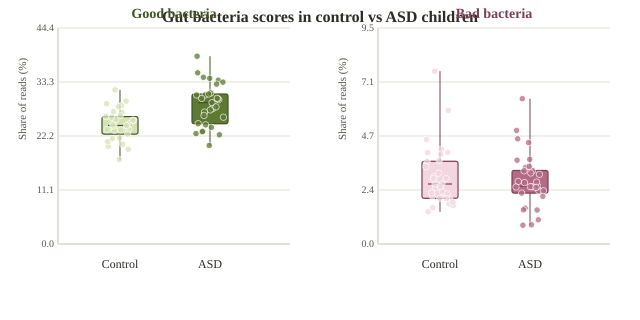

In [17]:
fn quartiles(mut xs: Vec<f64>) -> (f64, f64, f64, f64, f64) {
    xs.sort_by(|a, b| a.partial_cmp(b).unwrap());
    let q = |p: f64| {
        let i = (p * (xs.len() as f64 - 1.0)).floor() as usize;
        xs[i]
    };
    (xs[0], q(0.25), q(0.5), q(0.75), *xs.last().unwrap())
}

fn jitter(i: usize, n: usize) -> f64 {
    let u = ((i.wrapping_mul(1103515245) + 12345) % 1000) as f64 / 1000.0;
    (u - 0.5) * 28.0
}

fn panel_svg(title: &str, ctrl: &[f64], asd: &[f64], fill_c: &str, fill_a: &str, edge: &str, y_max: f64, x0: f64) -> String {
    let w = 280.0;
    let h = 280.0;
    let left = 48.0;
    let bottom = 36.0;
    let top = 28.0;
    let plot_h = h - top - bottom;
    let yx = |v: f64| top + plot_h * (1.0 - v / y_max);
    let mut s = String::new();
    s.push_str(&format!("<g transform='translate({x0},0)'>"));
    s.push_str(&format!("<text x='{:.1}' y='18' text-anchor='middle' font-size='14' font-weight='600' fill='{edge}'>{title}</text>", left + (w-left)/2.0));
    s.push_str(&format!("<line x1='{left}' y1='{top}' x2='{left}' y2='{:.1}' stroke='#C9C3B8'/>", h-bottom));
    s.push_str(&format!("<line x1='{left}' y1='{:.1}' x2='{w}' y2='{:.1}' stroke='#C9C3B8'/>", h-bottom, h-bottom));
    for tick in 0..5 {
        let v = y_max * tick as f64 / 4.0;
        let y = yx(v);
        s.push_str(&format!("<line x1='{left}' y1='{y:.1}' x2='{w}' y2='{y:.1}' stroke='#E6E1D8'/>"));
        s.push_str(&format!("<text x='44' y='{:.1}' text-anchor='end' font-size='10' fill='#5A554E'>{:.1}</text>", y + 3.0, v * 100.0));
    }
    let groups = [("Control", ctrl, fill_c, 110.0), ("ASD", asd, fill_a, 200.0)];
    for (name, vals, fill, cx) in groups {
        let (mn, q1, med, q3, mx) = quartiles(vals.to_vec());
        let box_w = 36.0;
        s.push_str(&format!(
            "<rect x='{:.1}' y='{:.1}' width='{box_w}' height='{:.1}' fill='{fill}' stroke='{edge}' stroke-width='1.2' rx='2'/>",
            cx - box_w / 2.0, yx(q3), (yx(q1) - yx(q3)).abs().max(1.0)
        ));
        s.push_str(&format!("<line x1='{:.1}' y1='{:.1}' x2='{:.1}' y2='{:.1}' stroke='{edge}' stroke-width='1.2'/>", cx - 12.0, yx(med), cx + 12.0, yx(med)));
        s.push_str(&format!("<line x1='{cx}' y1='{:.1}' x2='{cx}' y2='{:.1}' stroke='{edge}'/>", yx(q3), yx(mx)));
        s.push_str(&format!("<line x1='{cx}' y1='{:.1}' x2='{cx}' y2='{:.1}' stroke='{edge}'/>", yx(q1), yx(mn)));
        for (i, v) in vals.iter().enumerate() {
            let x = cx + jitter(i, vals.len());
            let y = yx(*v);
            s.push_str(&format!("<circle cx='{x:.1}' cy='{y:.1}' r='3.2' fill='{fill}' stroke='white' stroke-width='0.8' opacity='0.75'/>"));
        }
        s.push_str(&format!("<text x='{cx}' y='{:.1}' text-anchor='middle' font-size='12' fill='#2F2B26'>{name}</text>", h - 12.0));
    }
    s.push_str(&format!("<text x='16' y='{:.1}' transform='rotate(-90 16 {:.1})' font-size='11' fill='#5A554E'>Share of reads (%)</text>", h/2.0, h/2.0));
    s.push_str("</g>");
    s
}

let good_max = good_asd.iter().chain(&good_ctrl).cloned().fold(0.0, f64::max) * 1.15;
let bad_max = bad_asd.iter().chain(&bad_ctrl).cloned().fold(0.0, f64::max) * 1.25;
let svg = format!(
    "<svg xmlns='http://www.w3.org/2000/svg' width='640' height='320' style='background:#FBF9F6'>\
     <text x='320' y='22' text-anchor='middle' font-size='16' font-weight='600' fill='#2F2B26'>Gut bacteria scores in control vs ASD children</text>\
     {}{}</svg>",
    panel_svg("Good bacteria", &good_ctrl, &good_asd, "#D7E2B4", "#5E7A32", "#3F5320", good_max, 10.0),
    panel_svg("Bad bacteria", &bad_ctrl, &bad_asd, "#F3D6E0", "#B56B86", "#7A3F56", bad_max, 330.0),
);
println!("EVCXR_BEGIN_CONTENT image/svg+xml\n{svg}\nEVCXR_END_CONTENT");

## What to remember about ownership

- The CSV table **owns** the taxon names and counts. Analysis functions take `&AbundanceTable` or `&[f64]` so they look without taking.
- `let moved = taxa` empties `taxa`. `.clone()` pays for a second list. `&taxa` is a loan.
- Many `&` readers at once is fine. A `&mut` writer has to be alone. That is why the `push` while looping would not compile.
- OLS here is the same model as Python. The compiler already knew the score vectors were uniquely owned, which is the same idea Polars relies on in its Rust engine.
